# CT-RATE-AD Label Exploration

This notebook explores the labels for CT-RATE-AD dataset before data splits and model training.

The Goal is to understand label distribution and patient structure that helps deciding about spliting strateghy. 

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load the raw label file

Load the GPT generated labels and check the basic structure: shape, columns, 
missing values.

In [27]:
LABELS_PATH = "../data/raw/CT-RATE_reports_full_gpt-oss-120b.xlsx"

df = pd.read_excel(LABELS_PATH)

print("Shape of labels:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:", df.dtypes)
print("\nMissing Values:", df.isnull().sum())

Shape of labels: (50188, 7)

Columns: ['Predicted_label', 'VolumeName', 'Findings_EN', 'Impressions_EN', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6']

Data Types: Predicted_label     int64
VolumeName         object
Findings_EN        object
Impressions_EN     object
Unnamed: 4         object
Unnamed: 5         object
Unnamed: 6         object
dtype: object

Missing Values: Predicted_label        0
VolumeName             0
Findings_EN            2
Impressions_EN        28
Unnamed: 4         50170
Unnamed: 5         50185
Unnamed: 6         50187
dtype: int64


The Excel file for labels contains three unnamed columns that are almost empty. Drop them and keep only the relevant columns.

In [28]:
# drop unnamed and empty columns
df = df[["Predicted_label", "VolumeName", "Findings_EN", "Impressions_EN"]].copy()
print("Shape after dropping empty columns:", df.shape)
print("\nFirst rows:")
df.head()

Shape after dropping empty columns: (50188, 4)

First rows:


,Predicted_label,VolumeName,Findings_EN,Impressions_EN
0,2,train_1_a_1.nii.gz,Multiple venous collaterals are present in the...,Multiple venous collaterals in the anterior l...
1,2,train_1_a_2.nii.gz,Multiple venous collaterals are present in the...,Multiple venous collaterals in the anterior l...
2,2,train_2_a_1.nii.gz,Trachea and both main bronchi were in the midl...,Emphysematous and passive atelectatic changes...
3,2,train_2_a_2.nii.gz,Trachea and both main bronchi were in the midl...,Emphysematous and passive atelectatic changes...
4,2,train_3_a_1.nii.gz,Right thyroid lobe sizes increased. Evaluation...,Calcific atheromatous plaques in coronary art...


## 2. Label distribution

Labels: `0 = healthy`, `1 = borderline`, `2 = unhealthy`.

Check how the dataset is distributed across each label.

Number of volumes per label:
healthy (0): 6727 volumes (13.4%)
borderline (1): 3991 volumes (7.95%)
unhealthy (2): 39470 volumes (78.64%)


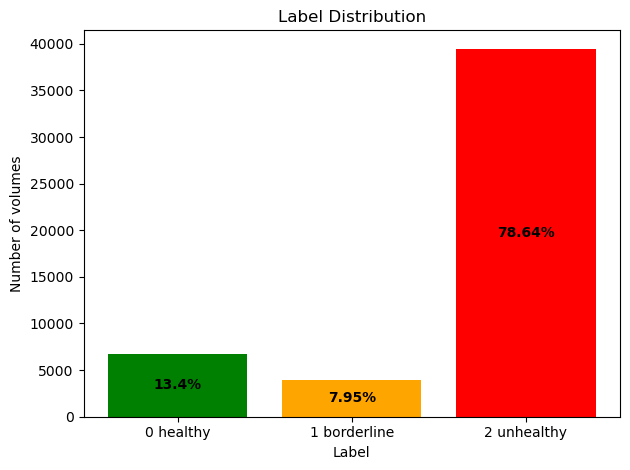

In [29]:
LABEL_MAP = {0: "healthy", 1: "borderline", 2: "unhealthy"}

label_counts = df["Predicted_label"].value_counts().sort_index()
label_percentage = (label_counts / len(df) * 100).round(2)

print("Number of volumes per label:")
for label, count in label_counts.items():
    print(f"{LABEL_MAP[label]} ({label}): {count} volumes ({label_percentage[label]}%)")


# plot the label distribution
labels = ["0 healthy", "1 borderline", "2 unhealthy"]
bars = plt.bar(labels, label_counts, color=["green", "orange", "red"])
plt.bar_label(bars, labels=[f"{p}%" for p in label_percentage], label_type="center", weight="bold")

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Number of volumes")

plt.tight_layout()
plt.show()

## 3. Parse volume names: patient, scan and reconstruction

Each `VolumeName` has the following structure, e.g. `train_50_b_3.nii.gz`:
- `patient_id = train_50` : the patient
- `scan_id = b` : a specific scan for that patient
- `reconstruction = 3` : a reconstruction of the same scan 

Note: All volumes with the same scan of a patient must be in the same data split to avoid data leakage.

In [30]:
def parse_volume_name(volume_name):
    """
    Parses the volume name to extract metadata such as patient ID, scan ID, and reconstruction number.

    Args:
        volume_name: The name of the volume, expected in the format "PatientID_ScanID_Reconstruction.nii.gz"
       
    Returns:
        dict: A dictionary containing the extracted metadata with keys "patient_id", "scan_id", and "reconstruction".
    """

    volume_metadata = {"patient_id": None, "scan_id": None, "reconstruction": None}

    str_parts = volume_name.replace(".nii.gz", "").split("_")

    if len(str_parts) == 4:
        volume_metadata["patient_id"] = str_parts[0] + "_" + str_parts[1]
        volume_metadata["scan_id"] = str_parts[2]
        volume_metadata["reconstruction"] = int(str_parts[3])

    return volume_metadata

metadata = df["VolumeName"].apply(parse_volume_name).apply(pd.Series)
processed_df = pd.concat([df, metadata], axis=1)

print("Null patient_ids:", processed_df["patient_id"].isnull().sum())
print("Unique patients:", processed_df["patient_id"].nunique())

print("Shape:", processed_df.shape)

print("\nFirst rows of df after parsing the volume names:")
processed_df.head()


Null patient_ids: 0
Unique patients: 21304
Shape: (50188, 7)

First rows of df after parsing the volume names:


,Predicted_label,VolumeName,Findings_EN,Impressions_EN,patient_id,scan_id,reconstruction
0,2,train_1_a_1.nii.gz,Multiple venous collaterals are present in the...,Multiple venous collaterals in the anterior l...,train_1,a,1
1,2,train_1_a_2.nii.gz,Multiple venous collaterals are present in the...,Multiple venous collaterals in the anterior l...,train_1,a,2
2,2,train_2_a_1.nii.gz,Trachea and both main bronchi were in the midl...,Emphysematous and passive atelectatic changes...,train_2,a,1
3,2,train_2_a_2.nii.gz,Trachea and both main bronchi were in the midl...,Emphysematous and passive atelectatic changes...,train_2,a,2
4,2,train_3_a_1.nii.gz,Right thyroid lobe sizes increased. Evaluation...,Calcific atheromatous plaques in coronary art...,train_3,a,1


## 4. Volumes per patient

How many CT volumes does each patient have on average?

In [ ]:
volumes_per_patient = processed_df.groupby("patient_id")["VolumeName"].count()

print("Volumes per patient:")
print(f"  min:    {volumes_per_patient.min()}")
print(f"  max:    {volumes_per_patient.max()}")
print(f"  mean:   {volumes_per_patient.mean():.2f}")
print(f"  median: {volumes_per_patient.median():.2f}")

print("\nVolumes per Patient Distribution:")
patient_dist = volumes_per_patient.value_counts().sort_index()

patient_dist_df = pd.DataFrame({
    "n_patients": patient_dist,
    "percentage": (patient_dist / len(volumes_per_patient) * 100).round(1)
})

patient_dist_df


Volumes per patient:
  min:    1
  max:    32
  mean:   2.36
  median: 2.00

Volumes per Patient Distribution:


,n_patients,percentage%
VolumeName,,
1,1744,8.2
2,16490,77.4
3,252,1.2
4,1747,8.2
5,267,1.3
6,403,1.9
7,54,0.3
8,154,0.7
9,19,0.1


## 5. Scans per patient

One patient can have multiple scans over time. How many scans does each patient have on average?

In [ ]:
scans_per_patient = processed_df.groupby("patient_id")["scan_id"].nunique()

print("Scans per patient:")
print(f"  min:    {scans_per_patient.min()}")
print(f"  max:    {scans_per_patient.max()}")
print(f"  mean:   {scans_per_patient.mean():.2f}")
print(f"  median: {scans_per_patient.median():.2f}")

print("\nScans per Patient Distribution:")
scan_dist = scans_per_patient.value_counts().sort_index()

scan_dist_df = pd.DataFrame({
    "n_patients": scan_dist,
    "percentage": (scan_dist / len(scans_per_patient) * 100).round(3)
})

scan_dist_df

Scans per patient:
  min:    1
  max:    17
  mean:   1.21
  median: 1.00

Scans per Patient Distribution:


,n_patients,percentage%
scan_id,,
1,18497,86.824
2,1981,9.299
3,467,2.192
4,185,0.868
5,81,0.380
6,46,0.216
7,13,0.061
8,15,0.070
9,9,0.042


## 6. Label consistency per patient

Since a patient can have multiple scans at different times, they can be healthy in one scan and unhealthy in another. Check how often this happens.

In [33]:
label_consistency = processed_df.groupby("patient_id")["Predicted_label"].nunique()

print("Label consistency per patient:")
print(f"patients with 1 unique label: {(label_consistency == 1).sum()}")
print(f"patients with 2 unique labels: {(label_consistency == 2).sum()}")
print(f"patients with 3 unique labels: {(label_consistency == 3).sum()}")

Label consistency per patient:
patients with 1 unique label: 20221
patients with 2 unique labels: 1044
patients with 3 unique labels: 39


For patients with more than one unique label, show exactly which label combinations they have.

In [ ]:
label_combinations = processed_df.groupby("patient_id")["Predicted_label"].apply(lambda x: tuple(sorted(x.unique())))

combinations_counts = label_combinations.value_counts().reset_index()
combinations_counts.columns = ["label_combination", "n_patients"]
combinations_counts["percentage"] = (combinations_counts["n_patients"] / len(label_consistency) * 100).round(1)

combinations_counts

,label_combination,n_patients,percentage%
0,"(2,)",16134,75.7
1,"(0,)",3008,14.1
2,"(1,)",1079,5.1
3,"(1, 2)",717,3.4
4,"(0, 2)",279,1.3
5,"(0, 1)",48,0.2
6,"(0, 1, 2)",39,0.2


## Find problematic labels

In [20]:
# find all scans with mixed labels
scan_label_diversity = df_filtered.groupby(["patient_id", "scan_id"])["Predicted_label"].nunique()
mixed_scans = scan_label_diversity[scan_label_diversity > 1].reset_index()
mixed_scans.columns = ["patient_id", "scan_id", "n_unique_labels"]

print(f"Total mixed-label scans: {len(mixed_scans)}")

# get all volumes belonging to those scans
mixed_volumes = df_filtered.merge(
    mixed_scans[["patient_id", "scan_id"]],
    on=["patient_id", "scan_id"],
    how="inner"
)

print(f"Total volumes in mixed scans: {len(mixed_volumes)}")
print("\nSample — one mixed scan:")
example = mixed_volumes.groupby(["patient_id", "scan_id"]).first().index[0]
print(df_filtered[
    (df_filtered["patient_id"] == example[0]) &
    (df_filtered["scan_id"] == example[1])
][["VolumeName", "scan_id", "reconstruction", "Predicted_label"]])

Total mixed-label scans: 81
Total volumes in mixed scans: 162

Sample — one mixed scan:
                   VolumeName scan_id  reconstruction  Predicted_label
24599  train_10394_a_1.nii.gz       a               1                1
24600  train_10394_a_2.nii.gz       a               2                0


In [21]:
mixed_volumes.to_csv("../data/raw/mixed_label_scans.csv", index=False)
print(f"Saved mixed_label_scans.csv with {len(mixed_volumes)} volumes from {len(mixed_scans)} scans")

Saved mixed_label_scans.csv with 162 volumes from 81 scans


In [22]:
# for each scan, check if all volumes have the same Findings_EN and Impressions_EN
scan_text_diversity = df_filtered.groupby(["patient_id", "scan_id"]).agg(
    unique_findings=("Findings_EN", "nunique"),
    unique_impressions=("Impressions_EN", "nunique")
).reset_index()

# merge with mixed scans only
mixed_text = mixed_volumes.groupby(["patient_id", "scan_id"]).agg(
    unique_findings=("Findings_EN", "nunique"),
    unique_impressions=("Impressions_EN", "nunique")
).reset_index()

print("Among 81 mixed-label scans:")
print(f"  same Findings AND same Impressions: {((mixed_text['unique_findings'] == 1) & (mixed_text['unique_impressions'] == 1)).sum()}")
print(f"  different Findings or Impressions:  {((mixed_text['unique_findings'] > 1) | (mixed_text['unique_impressions'] > 1)).sum()}")

Among 81 mixed-label scans:
  same Findings AND same Impressions: 81
  different Findings or Impressions:  0
